<a href="https://colab.research.google.com/github/alyssapalms/Assignment10/blob/main/Assignment12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

Load CIFAR-10 dataset

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(50000, 32, 32, 3)
(50000,)
(10000, 32, 32, 3)
(10000,)


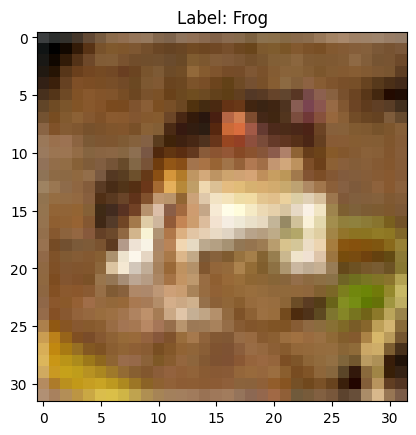

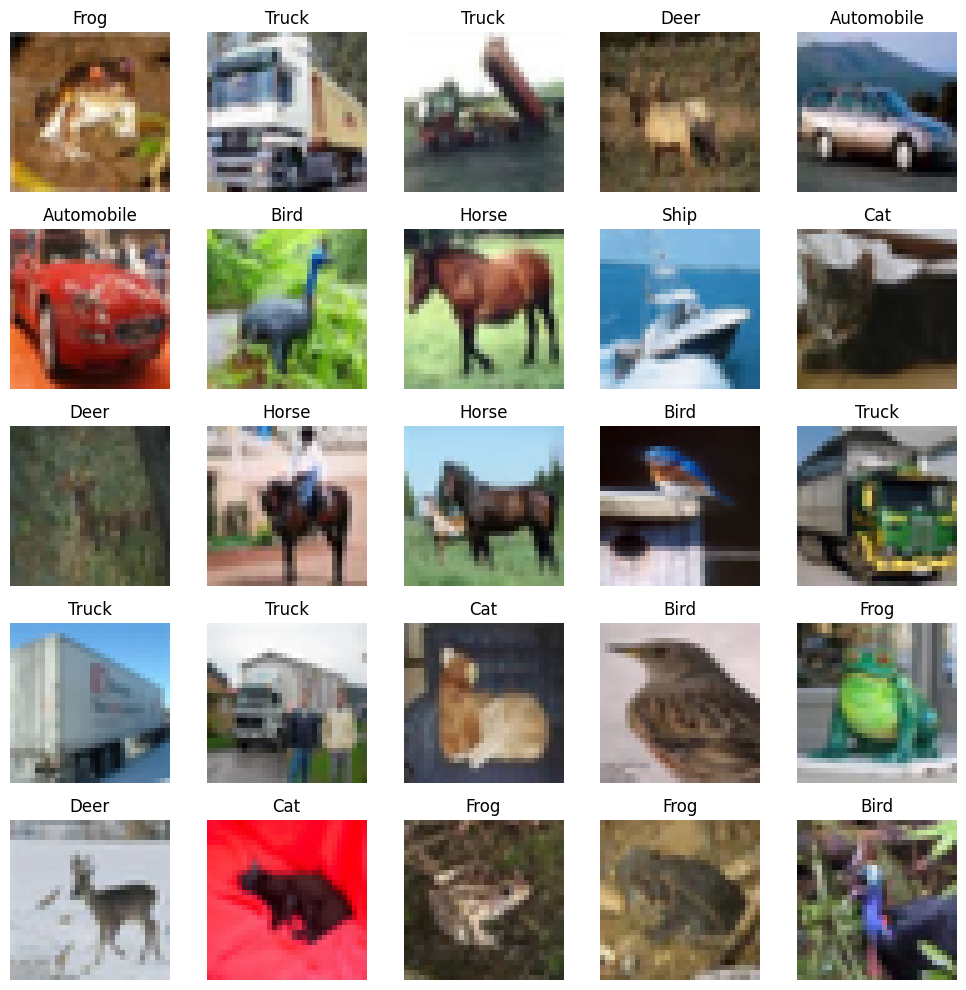

In [2]:
from tensorflow.keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Flatten labels into 1D
y_train = y_train.flatten()
y_test = y_test.flatten()

# Print dataset shapes
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# CIFAR-10 class names
class_names = [
    "Airplane","Automobile","Bird","Cat","Deer",
    "Dog","Frog","Horse","Ship","Truck"
]

# Show first training image
plt.imshow(X_train[0])
plt.title(f"Label: {class_names[y_train[0]]}")
plt.show()

# Plot first 25 images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

Normalize data

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

encode labels

In [4]:
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

ANN

In [5]:
ann = tf.keras.models.Sequential()

ann.add(tf.keras.layers.Flatten(input_shape=(32,32,3)))
ann.add(tf.keras.layers.Dense(units=128, activation='relu'))
ann.add(tf.keras.layers.Dense(units=64, activation='relu'))
ann.add(tf.keras.layers.Dense(units=10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile the model

In [6]:
ann.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train the model

In [7]:
history = ann.fit(
    X_train, y_train_cat,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.2521 - loss: 2.0531 - val_accuracy: 0.3481 - val_loss: 1.8095
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3720 - loss: 1.7662 - val_accuracy: 0.3858 - val_loss: 1.7220
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4042 - loss: 1.6785 - val_accuracy: 0.4035 - val_loss: 1.6774
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4293 - loss: 1.6124 - val_accuracy: 0.4055 - val_loss: 1.6639
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4398 - loss: 1.5739 - val_accuracy: 0.4326 - val_loss: 1.6103
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.4532 - loss: 1.5330 - val_accuracy: 0.4082 - val_loss: 1.6447
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4591 - loss: 1.5245 - val_accuracy: 0.4483 - val_loss: 1.5648
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4745 - loss: 1.4811 - val_ac

Evaluate the model

In [8]:
test_loss, test_acc = ann.evaluate(X_test, y_test_cat)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4527 - loss: 1.5226
Test Accuracy: 0.4514000117778778


Predictions

In [9]:
y_pred_probs = ann.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


confusion matrix

[[680  22  44  14  30  18  21  42 120   9]
 [133 552  15  24  15  41  21  41 105  53]
 [146  25 293  49 164 116  82  85  34   6]
 [ 69  18  87 206  62 303 100  92  48  15]
 [ 85  13 162  40 395  85  80 104  35   1]
 [ 47  18  97 101  72 445  61 105  48   6]
 [ 32   8  91  58 164 108 463  51  19   6]
 [ 80  13  66  35  87  77  23 575  22  22]
 [222  54   9  15  26  22   5  22 606  19]
 [155 217  12  30  23  34  32  78 120 299]]


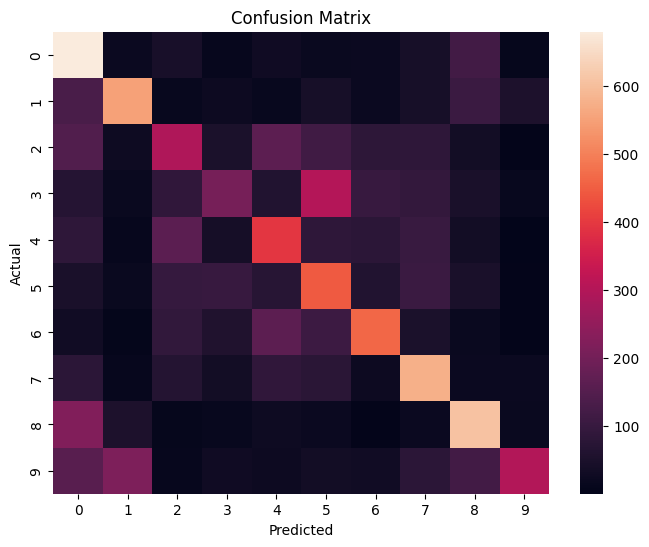

In [10]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

report

In [11]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.41      0.68      0.51      1000
  Automobile       0.59      0.55      0.57      1000
        Bird       0.33      0.29      0.31      1000
         Cat       0.36      0.21      0.26      1000
        Deer       0.38      0.40      0.39      1000
         Dog       0.36      0.45      0.40      1000
        Frog       0.52      0.46      0.49      1000
       Horse       0.48      0.57      0.52      1000
        Ship       0.52      0.61      0.56      1000
       Truck       0.69      0.30      0.42      1000

    accuracy                           0.45     10000
   macro avg       0.46      0.45      0.44     10000
weighted avg       0.46      0.45      0.44     10000

